In [11]:
df[df.neutral==True]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
68,1890-02-08,Wales,Northern Ireland,5.0,2.0,British Home Championship,Shrewsbury,England,True
203,1907-03-21,Alderney,Jersey,1.0,2.0,Muratti Vase,Guernsey,Guernsey,True
219,1908-04-02,Guernsey,Alderney,3.0,0.0,Muratti Vase,Jersey,Jersey,True
238,1908-10-22,France,Denmark,1.0,17.0,Olympic Games,London,England,True
239,1908-10-23,Netherlands,Sweden,2.0,0.0,Olympic Games,London,England,True
...,...,...,...,...,...,...,...,...,...
49500,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,Vancouver,Canada,True
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True


In [1]:
import joblib

model = joblib.load("../models/classifier.pkl")
scaler = joblib.load("../models/scaler.pkl")

print("Classes:", model.classes_)
print("Coefficients:\n", model.coef_)
print("Intercepts:", model.intercept_)
print("Scaler expects this many features:", scaler.n_features_in_)

Classes: [0 1 2]
Coefficients:
 [[-0.72242213  0.15704846]
 [-0.01629531 -0.0038432 ]
 [ 0.73871744 -0.15320527]]
Intercepts: [-0.13453221  0.12283842  0.01169379]
Scaler expects this many features: 2


In [9]:
import pandas as pd
df = pd.read_csv("../data/processed/training_data.csv")
print(df["outcome"].value_counts(normalize=True))

outcome
2    0.480684
0    0.281523
1    0.237793
Name: proportion, dtype: float64


this formula:

y1=m1x1+ m2x2 + b1
y2=m3x1+ m4x2 + b2
y3=m5x1+ m6x2 + b3

y1 - awaywin
y2 - draw
y3 - homewin

In [11]:
for rd in [-150, -100, -50, -20, -10, -5, 0, 5, 10, 20, 50, 100, 150]:
    for neutral in [0, 1]:
        X = pd.DataFrame([[rd, neutral]], columns=["rank_diff", "neutral_venue"])
        X_scaled = scaler.transform(X)
        probs = model.predict_proba(X_scaled)[0]
        print(f"rank_diff={rd:>5}  neutral={neutral}  ->  away={probs[0]:.2f}  draw={probs[1]:.2f}  home={probs[2]:.2f}")

rank_diff= -150  neutral=0  ->  away=0.84  draw=0.13  home=0.03
rank_diff= -150  neutral=1  ->  away=0.89  draw=0.10  home=0.02
rank_diff= -100  neutral=0  ->  away=0.69  draw=0.21  home=0.09
rank_diff= -100  neutral=1  ->  away=0.78  draw=0.17  home=0.05
rank_diff=  -50  neutral=0  ->  away=0.47  draw=0.28  home=0.25
rank_diff=  -50  neutral=1  ->  away=0.59  draw=0.25  home=0.16
rank_diff=  -20  neutral=0  ->  away=0.32  draw=0.29  home=0.40
rank_diff=  -20  neutral=1  ->  away=0.44  draw=0.28  home=0.28
rank_diff=  -10  neutral=0  ->  away=0.27  draw=0.28  home=0.45
rank_diff=  -10  neutral=1  ->  away=0.39  draw=0.28  home=0.33
rank_diff=   -5  neutral=0  ->  away=0.25  draw=0.28  home=0.47
rank_diff=   -5  neutral=1  ->  away=0.37  draw=0.28  home=0.35
rank_diff=    0  neutral=0  ->  away=0.23  draw=0.27  home=0.50
rank_diff=    0  neutral=1  ->  away=0.34  draw=0.28  home=0.38
rank_diff=    5  neutral=0  ->  away=0.21  draw=0.27  home=0.52
rank_diff=    5  neutral=1  ->  away=0.3

In [13]:
df = pd.read_csv("../data/processed/training_data.csv")
print(df["rank_diff"].describe())
print("Fraction of matches where home team is better ranked:", (df["rank_diff"] > 0).mean())

count    23348.000000
mean         3.715693
std         54.207344
min       -210.000000
25%        -29.000000
50%          5.000000
75%         37.000000
max        209.000000
Name: rank_diff, dtype: float64
Fraction of matches where home team is better ranked: 0.5376049340414597


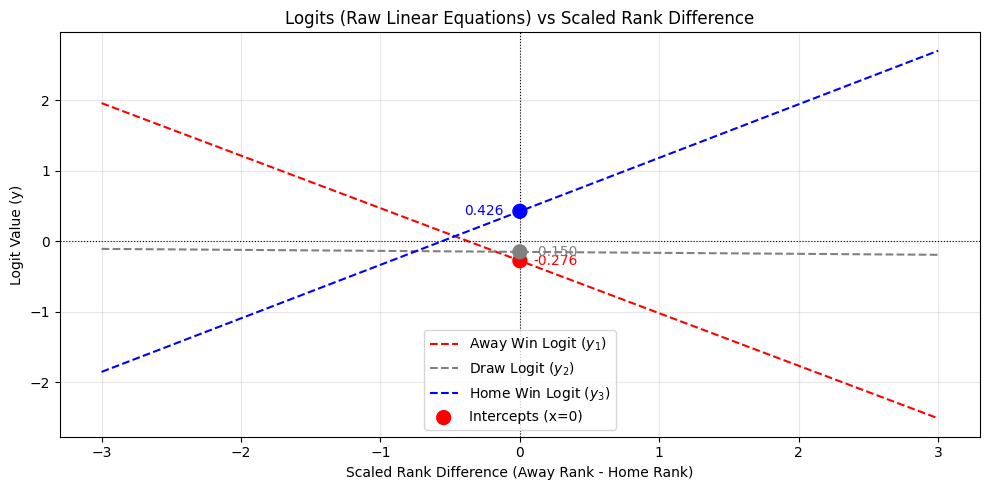

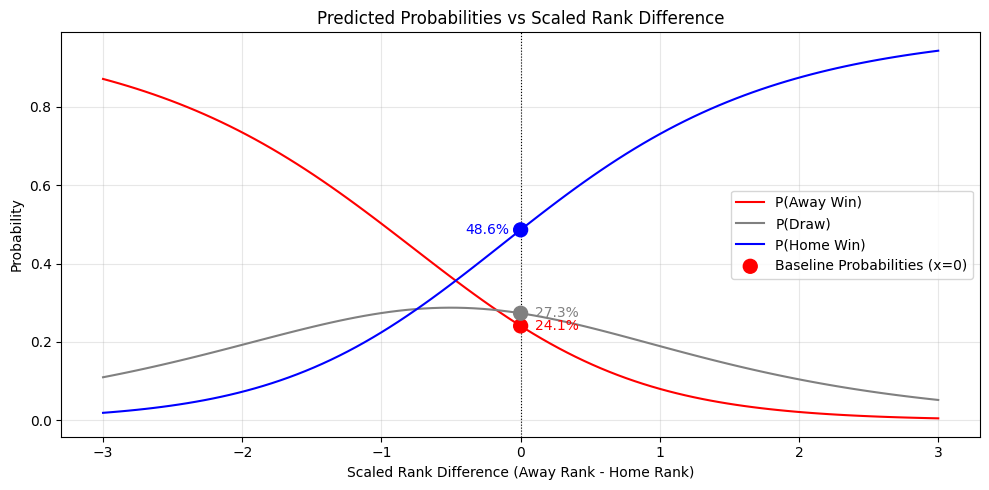

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a range of scaled rank_diff values
x1 = np.linspace(-3, 3, 100)
x2 = 0 

# Intercepts
b1 = -0.276
b2 = -0.150
b3 = 0.426

# The three linear equations (Logits)
y1 = -0.746 * x1 + 0.153 * x2 + b1  # Away Win
y2 = -0.014 * x1 - 0.004 * x2 + b2  # Draw
y3 =  0.760 * x1 - 0.149 * x2 + b3  # Home Win

# --- PLOT 1: The Three Lines (Logits) ---
plt.figure(figsize=(10, 5))
plt.plot(x1, y1, label="Away Win Logit ($y_1$)", color="red", linestyle="--")
plt.plot(x1, y2, label="Draw Logit ($y_2$)", color="gray", linestyle="--")
plt.plot(x1, y3, label="Home Win Logit ($y_3$)", color="blue", linestyle="--")

# Plot the intercepts as points at x=0
plt.scatter([0, 0, 0], [b1, b2, b3], color=['red', 'gray', 'blue'], zorder=5, s=100, label="Intercepts (x=0)")

# Add text labels for the intercepts
plt.text(0.1, b1, f"{b1:.3f}", color='red', va='center')
plt.text(0.1, b2, f"{b2:.3f}", color='gray', va='center')
plt.text(-0.4, b3, f"{b3:.3f}", color='blue', va='center') # shifted left slightly to avoid line overlap

plt.title("Logits (Raw Linear Equations) vs Scaled Rank Difference")
plt.xlabel("Scaled Rank Difference (Away Rank - Home Rank)")
plt.ylabel("Logit Value (y)")
plt.axvline(0, color='black', linewidth=0.8, linestyle=":")
plt.axhline(0, color='black', linewidth=0.8, linestyle=":")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 2: The Probabilities (Softmax) ---
exp_y1 = np.exp(y1)
exp_y2 = np.exp(y2)
exp_y3 = np.exp(y3)
sum_exp = exp_y1 + exp_y2 + exp_y3

p1 = exp_y1 / sum_exp
p2 = exp_y2 / sum_exp
p3 = exp_y3 / sum_exp

# Calculate the probability intercepts exactly at x=0
exp_b1 = np.exp(b1)
exp_b2 = np.exp(b2)
exp_b3 = np.exp(b3)
sum_exp_b = exp_b1 + exp_b2 + exp_b3

p_b1 = exp_b1 / sum_exp_b
p_b2 = exp_b2 / sum_exp_b
p_b3 = exp_b3 / sum_exp_b

plt.figure(figsize=(10, 5))
plt.plot(x1, p1, label="P(Away Win)", color="red")
plt.plot(x1, p2, label="P(Draw)", color="gray")
plt.plot(x1, p3, label="P(Home Win)", color="blue")

# Plot the intercepts as points on the probability curves
plt.scatter([0, 0, 0], [p_b1, p_b2, p_b3], color=['red', 'gray', 'blue'], zorder=5, s=100, label="Baseline Probabilities (x=0)")

# Add text labels for the intercept probabilities
plt.text(0.1, p_b1, f"{p_b1:.1%}", color='red', va='center')
plt.text(0.1, p_b2, f"{p_b2:.1%}", color='gray', va='center')
plt.text(-0.4, p_b3, f"{p_b3:.1%}", color='blue', va='center')

plt.title("Predicted Probabilities vs Scaled Rank Difference")
plt.xlabel("Scaled Rank Difference (Away Rank - Home Rank)")
plt.ylabel("Probability")
plt.axvline(0, color='black', linewidth=0.8, linestyle=":")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
